In [1]:
!pip install -q torch torchvision scikit-learn seaborn tqdm transformers

In [2]:
import os
import copy
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch:', torch.__version__)

Device: cuda
PyTorch: 2.9.0+cu126


<a id="section-3-locate-dataset"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>📂</span> 3. Locate Dataset Automatically
    </h2>
</div>

In [4]:
candidate_paths = [
    Path('/kaggle/input/datasets/joebeachcapital/realwaste/realwaste-main/RealWaste'),
]

def is_dataset_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [p for p in path.iterdir() if p.is_dir()]
    if len(class_dirs) < 2:
        return False
    has_images = any(any(c.glob('*.jpg')) or any(c.glob('*.jpeg')) or any(c.glob('*.png')) for c in class_dirs)
    return has_images

data_dir = None
for p in candidate_paths:
    if is_dataset_root(p):
        data_dir = p
        break

if data_dir is None:
    raise FileNotFoundError('No valid dataset root found. Update candidate_paths manually.')

print('Using dataset path:', data_dir)

Using dataset path: /kaggle/input/datasets/joebeachcapital/realwaste/realwaste-main/RealWaste


<a id="section-4-build-file-index"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>📊</span> 4. Build File Index and Inspect Class Balance
    </h2>
</div>

Total images: 4752
Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


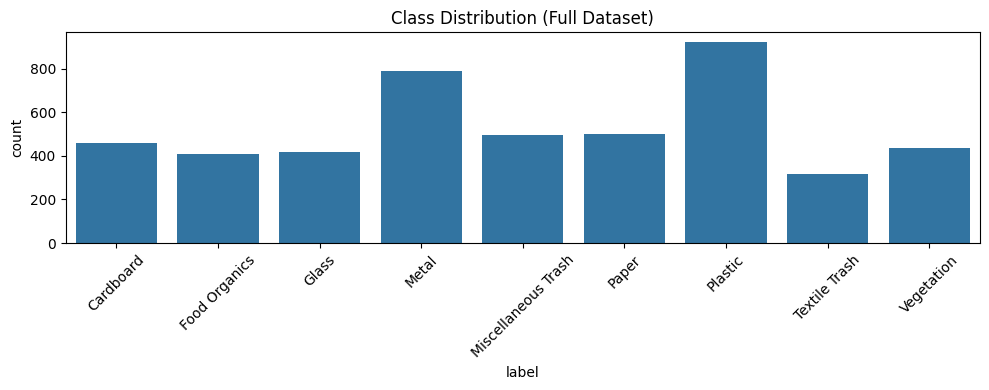

In [5]:
valid_ext = {'.jpg', '.jpeg', '.png'}
records = []

class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}

for cls in class_names:
    cls_dir = data_dir / cls
    for img_path in cls_dir.rglob('*'):
        if img_path.suffix.lower() in valid_ext:
            records.append({'filepath': str(img_path), 'label': cls, 'label_idx': class_to_idx[cls]})

df = pd.DataFrame(records)
print('Total images:', len(df))
print('Classes:', class_names)

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='label', order=class_names)
plt.xticks(rotation=45)
plt.title('Class Distribution (Full Dataset)')
plt.tight_layout()
plt.show()

<a id="section-5-stratified-split"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>⚙️</span> 5. Stratified Train / Validation / Test Split
    </h2>
</div>

In [6]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label_idx'],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label_idx'],
    random_state=SEED,
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = split['label'].value_counts().sort_index()
    print(f'\n{name} split class counts:')
    print(counts.to_string())

Train: 3801 | Val: 475 | Test: 476

Train split class counts:
label
Cardboard              369
Food Organics          329
Glass                  336
Metal                  632
Miscellaneous Trash    396
Paper                  400
Plastic                736
Textile Trash          254
Vegetation             349

Val split class counts:
label
Cardboard              46
Food Organics          41
Glass                  42
Metal                  79
Miscellaneous Trash    49
Paper                  50
Plastic                92
Textile Trash          32
Vegetation             44

Test split class counts:
label
Cardboard              46
Food Organics          41
Glass                  42
Metal                  79
Miscellaneous Trash    50
Paper                  50
Plastic                93
Textile Trash          32
Vegetation             43


<a id="section-6-dataset-transforms"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>🧪</span> 6. Dataset Class and Transforms
    </h2>
</div>

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class GarbageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            image = self.transform(image)
        return image, label

train_ds = GarbageDataset(train_df, transform=train_tfms)
val_ds = GarbageDataset(val_df, transform=val_test_tfms)
test_ds = GarbageDataset(test_df, transform=val_test_tfms)

print('Datasets ready.')

Datasets ready.


<a id="section-7-dataloaders"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>⚖️</span> 7. DataLoaders with Class-Imbalance Handling
    </h2>
</div>

In [8]:
train_labels = train_df['label_idx'].values
class_sample_count = np.array([np.sum(train_labels == t) for t in range(len(class_names))])
class_weights = 1.0 / np.maximum(class_sample_count, 1)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print('Loaders ready:', len(train_loader), len(val_loader), len(test_loader))

Loaders ready: 119 15 15


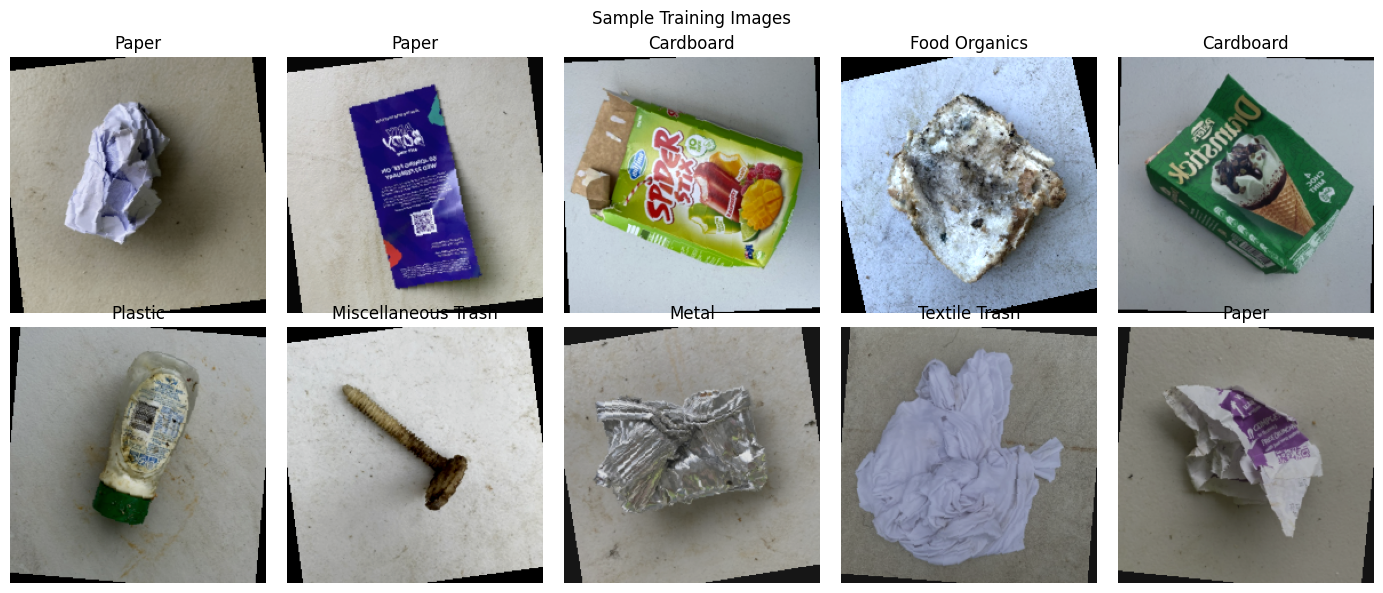

In [9]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    img = denormalize(images[i].cpu())
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_names[labels[i].item()])
    ax.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

<a id="section-8-build-model"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>🤖</span> 8. Build a Transfer Learning Model
    </h2>
</div>


Default is now a stronger backbone for higher accuracy: `efficientnet_b3`.

Supported backbones:
- `resnet50`
- `efficientnet_b0`
- `efficientnet_b3` (recommended)
- `mobilenet_v3_large`

In [10]:
from transformers import ViTForImageClassification, ViTImageProcessordef build_model(backbone: str, num_classes: int, freeze_features: bool = True):    """    Build Vision Transformer models from Hugging Face    Supported backbones:    - deit-tiny-patch16-224    - deit-small-patch16-224    - deit-base-patch16-224    """    if backbone == 'deit-tiny-patch16-224':        model_name = 'facebook/deit-tiny-patch16-224'        model = ViTForImageClassification.from_pretrained(            model_name,            num_labels=num_classes,            ignore_mismatched_sizes=True        )        feature_layers = [model.vit.embeddings, model.vit.encoder]    elif backbone == 'deit-small-patch16-224':        model_name = 'facebook/deit-small-patch16-224'        model = ViTForImageClassification.from_pretrained(            model_name,            num_labels=num_classes,            ignore_mismatched_sizes=True        )        feature_layers = [model.vit.embeddings, model.vit.encoder]    elif backbone == 'deit-base-patch16-224':        model_name = 'facebook/deit-base-patch16-224'        model = ViTForImageClassification.from_pretrained(            model_name,            num_labels=num_classes,            ignore_mismatched_sizes=True        )        feature_layers = [model.vit.embeddings, model.vit.encoder]    else:        raise ValueError(f'Unsupported backbone: {backbone}')    if freeze_features:        for module in feature_layers:            for p in module.parameters():                p.requires_grad = False    return modelBACKBONE = 'deit-tiny-patch16-224'  # Change to 'deit-small-patch16-224' or 'deit-base-patch16-224' to try other modelsmodel = build_model(BACKBONE, num_classes=len(class_names), freeze_features=True).to(device)trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)all_params = sum(p.numel() for p in model.parameters())print(f'Backbone: {BACKBONE}')print(f'Trainable params: {trainable_params:,} / {all_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 148MB/s] 


Backbone: efficientnet_b3
Trainable params: 13,833 / 10,710,065


<a id="section-9-training-utilities"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>🛠️</span> 9. Training Utilities
    </h2>
</div>

In [11]:
def accuracy_from_logits(logits, targets):    preds = logits.argmax(dim=1)    return (preds == targets).float().mean().item()@torch.no_grad()def evaluate(model, loader, criterion):    model.eval()    losses, accs = [], []    for images, targets in loader:        images, targets = images.to(device), targets.to(device)        outputs = model(images)        # ViT models return a ModelOutput object, extract logits        logits = outputs.logits if hasattr(outputs, 'logits') else outputs        loss = criterion(logits, targets)        losses.append(loss.item())        accs.append(accuracy_from_logits(logits, targets))    return float(np.mean(losses)), float(np.mean(accs))def train_one_epoch(model, loader, criterion, optimizer):    model.train()    losses, accs = [], []    for images, targets in loader:        images, targets = images.to(device), targets.to(device)        optimizer.zero_grad()        outputs = model(images)        # ViT models return a ModelOutput object, extract logits        logits = outputs.logits if hasattr(outputs, 'logits') else outputs        loss = criterion(logits, targets)        loss.backward()        optimizer.step()        losses.append(loss.item())        accs.append(accuracy_from_logits(logits, targets))    return float(np.mean(losses)), float(np.mean(accs))

<a id="section-10-stage1-training"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>🚀</span> 10. Train the Model (Stage 1)
    </h2>
</div>

In [12]:
EPOCHS = 10
LR = 1e-3

model, history_stage1 = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    patience=4,
)

history_stage1.tail()

Epoch 01/10 | lr 1.00e-03 | train_loss 1.4982 | train_acc 0.5669 | val_loss 1.1265 | val_acc 0.7026
Epoch 02/10 | lr 1.00e-03 | train_loss 0.9791 | train_acc 0.7025 | val_loss 1.0192 | val_acc 0.7356
Epoch 03/10 | lr 1.00e-03 | train_loss 0.8764 | train_acc 0.7142 | val_loss 0.8395 | val_acc 0.7360
Epoch 04/10 | lr 1.00e-03 | train_loss 0.7935 | train_acc 0.7499 | val_loss 0.7758 | val_acc 0.7543
Epoch 05/10 | lr 1.00e-03 | train_loss 0.7685 | train_acc 0.7457 | val_loss 0.7746 | val_acc 0.7509
Epoch 06/10 | lr 1.00e-03 | train_loss 0.7184 | train_acc 0.7636 | val_loss 0.8997 | val_acc 0.7485
Epoch 07/10 | lr 1.00e-03 | train_loss 0.6849 | train_acc 0.7722 | val_loss 0.7345 | val_acc 0.7568
Epoch 08/10 | lr 1.00e-03 | train_loss 0.6718 | train_acc 0.7724 | val_loss 0.7035 | val_acc 0.7439
Epoch 09/10 | lr 1.00e-03 | train_loss 0.6487 | train_acc 0.7784 | val_loss 0.8736 | val_acc 0.7651
Epoch 10/10 | lr 1.00e-03 | train_loss 0.6315 | train_acc 0.7928 | val_loss 0.6788 | val_acc 0.7647


,epoch,lr,train_loss,train_acc,val_loss,val_acc
5,6,0.001,0.718366,0.763550,0.899743,0.748457
6,7,0.001,0.684931,0.772216,0.734467,0.756790
7,8,0.001,0.671809,0.772363,0.703483,0.743904
8,9,0.001,0.648688,0.778403,0.873576,0.765123
9,10,0.001,0.631542,0.792847,0.678792,0.764738


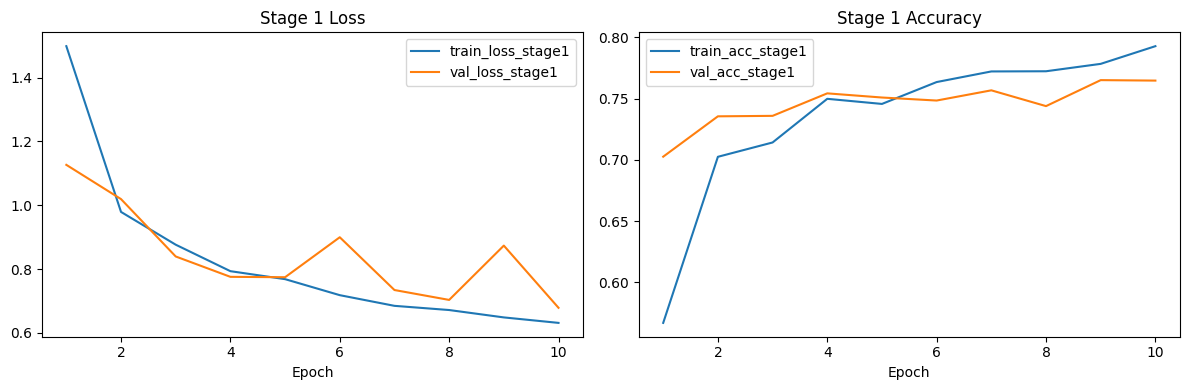

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_stage1['epoch'], history_stage1['train_loss'], label='train_loss_stage1')
axes[0].plot(history_stage1['epoch'], history_stage1['val_loss'], label='val_loss_stage1')
axes[0].set_title('Stage 1 Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_stage1['epoch'], history_stage1['train_acc'], label='train_acc_stage1')
axes[1].plot(history_stage1['epoch'], history_stage1['val_acc'], label='val_acc_stage1')
axes[1].set_title('Stage 1 Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="section-11-finetuning-evaluation"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>🎯</span> 11. Fine-Tuning + Final Evaluation
    </h2>
</div>



We unfreeze the feature extractor and continue training with a smaller learning rate to improve final accuracy.

Epoch 01/6 | lr 1.00e-04 | train_loss 0.5068 | train_acc 0.8310 | val_loss 0.5134 | val_acc 0.8214
Epoch 02/6 | lr 1.00e-04 | train_loss 0.3162 | train_acc 0.8955 | val_loss 0.8646 | val_acc 0.8627
Epoch 03/6 | lr 1.00e-04 | train_loss 0.2311 | train_acc 0.9232 | val_loss 0.3878 | val_acc 0.8589
Epoch 04/6 | lr 1.00e-04 | train_loss 0.1605 | train_acc 0.9492 | val_loss 0.5153 | val_acc 0.8676
Epoch 05/6 | lr 1.00e-04 | train_loss 0.1165 | train_acc 0.9630 | val_loss 0.3483 | val_acc 0.8767
Epoch 06/6 | lr 1.00e-04 | train_loss 0.1049 | train_acc 0.9674 | val_loss 0.3339 | val_acc 0.8996


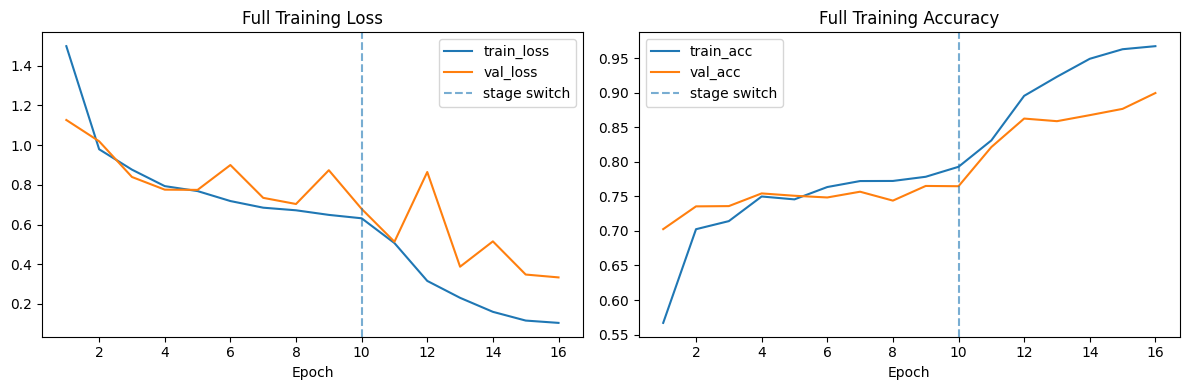

Test Accuracy: 0.8866

Classification Report:
                     precision    recall  f1-score   support

          Cardboard     0.9474    0.7826    0.8571        46
      Food Organics     0.8837    0.9268    0.9048        41
              Glass     0.9268    0.9048    0.9157        42
              Metal     0.8065    0.9494    0.8721        79
Miscellaneous Trash     0.8667    0.7800    0.8211        50
              Paper     0.8654    0.9000    0.8824        50
            Plastic     0.9070    0.8387    0.8715        93
      Textile Trash     0.9091    0.9375    0.9231        32
         Vegetation     0.9556    1.0000    0.9773        43

           accuracy                         0.8866       476
          macro avg     0.8964    0.8911    0.8917       476
       weighted avg     0.8899    0.8866    0.8858       476



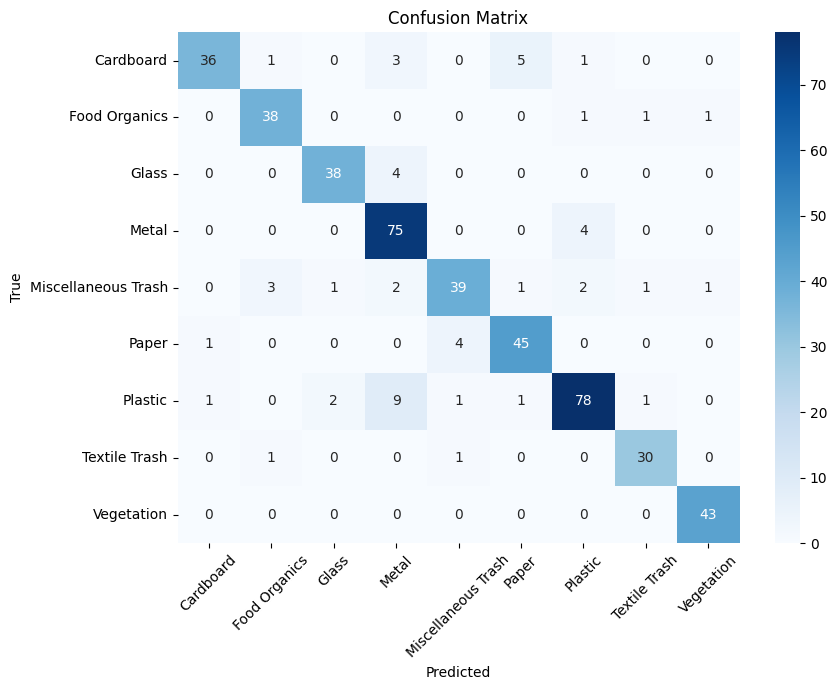

In [14]:
# Stage 2: unfreeze model for fine-tuning
for p in model.parameters():
    p.requires_grad = True

model, history_stage2 = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=6,
    lr=1e-4,
    weight_decay=1e-5,
    patience=3,
)

# Merge history for visualization
history_stage1 = history_stage1.copy()
history_stage2 = history_stage2.copy()
if len(history_stage2) > 0:
    history_stage2['epoch'] = history_stage2['epoch'] + history_stage1['epoch'].max()
history_all = pd.concat([history_stage1, history_stage2], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_all['epoch'], history_all['train_loss'], label='train_loss')
axes[0].plot(history_all['epoch'], history_all['val_loss'], label='val_loss')
axes[0].axvline(history_stage1['epoch'].max(), linestyle='--', alpha=0.6, label='stage switch')
axes[0].set_title('Full Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_all['epoch'], history_all['train_acc'], label='train_acc')
axes[1].plot(history_all['epoch'], history_all['val_acc'], label='val_acc')
axes[1].axvline(history_stage1['epoch'].max(), linestyle='--', alpha=0.6, label='stage switch')
axes[1].set_title('Full Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in loader:
        images = images.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.numpy().tolist())
    return np.array(all_targets), np.array(all_preds)

y_true, y_pred = predict_loader(model, test_loader)

test_acc = (y_true == y_pred).mean()
print(f'Test Accuracy: {test_acc:.4f}')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

overall_accuracy = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

print('=== Overall Metrics ===')
print(f'Accuracy      : {overall_accuracy:.4f}')
print(f'Precision(Ma) : {prec_macro:.4f}')
print(f'Recall(Ma)    : {rec_macro:.4f}')
print(f'F1-Score(Ma)  : {f1_macro:.4f}')
print(f'Precision(Wt) : {prec_weighted:.4f}')
print(f'Recall(Wt)    : {rec_weighted:.4f}')
print(f'F1-Score(Wt)  : {f1_weighted:.4f}')

p, r, f1, s = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(len(class_names))), zero_division=0
)

metrics_df = pd.DataFrame({
    'class': class_names,
    'precision': p,
    'recall': r,
    'f1_score': f1,
    'support': s,
}).sort_values('f1_score', ascending=False)

print('\n=== Per-Class Metrics (sorted by F1) ===')
display(metrics_df.style.format({
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1_score': '{:.4f}',
}))

=== Overall Metrics ===
Accuracy      : 0.8866
Precision(Ma) : 0.8964
Recall(Ma)    : 0.8911
F1-Score(Ma)  : 0.8917
Precision(Wt) : 0.8899
Recall(Wt)    : 0.8866
F1-Score(Wt)  : 0.8858

=== Per-Class Metrics (sorted by F1) ===


,class,precision,recall,f1_score,support
8,Vegetation,0.9556,1.0000,0.9773,43
7,Textile Trash,0.9091,0.9375,0.9231,32
2,Glass,0.9268,0.9048,0.9157,42
1,Food Organics,0.8837,0.9268,0.9048,41
5,Paper,0.8654,0.9000,0.8824,50
3,Metal,0.8065,0.9494,0.8721,79
6,Plastic,0.9070,0.8387,0.8715,93
0,Cardboard,0.9474,0.7826,0.8571,46
4,Miscellaneous Trash,0.8667,0.7800,0.8211,50


In [16]:
# Auto-highlight weaker classes and suggest targeted improvements

threshold_f1 = 0.93
fallback_top_n = 3

low_f1_df = metrics_df.sort_values('f1_score', ascending=True).copy()
flagged_df = low_f1_df[low_f1_df['f1_score'] < threshold_f1].copy()

if flagged_df.empty:
    flagged_df = low_f1_df.head(fallback_top_n).copy()

suggestion_map = {
    'trash': 'Increase samples + hard augmentations (random crop, blur, brightness/contrast).',
    'plastic': 'Add look-alike negatives (glass/metal) and use stronger color/texture augmentation.',
    'metal': 'Add edge/reflective examples and train with higher-resolution images (256/300).',
    'paper': 'Add crumpled/wet variants and background diversity.',
    'glass': 'Include transparent/reflective cases with varied lighting.',
    'battery': 'Add close-up and distance variants; balance orientation examples.',
    'cardboard': 'Add folded/torn variants and cluttered backgrounds.',
    'shoes': 'Use occlusion augmentation and mixed-background samples.',
    'biological': 'Include decomposition/shape diversity and lighting changes.',
    'clothes': 'Add texture and color diversity with background clutter.'
}

flagged_df['gap_to_0.95'] = (0.95 - flagged_df['f1_score']).clip(lower=0)
flagged_df['recommended_action'] = flagged_df['class'].map(suggestion_map).fillna(
    'Use class-focused augmentation + collect more hard samples for this class.'
)

print(f'=== Low-F1 Class Diagnostic (threshold: {threshold_f1:.2f}) ===')
print(f'Flagged classes: {len(flagged_df)}')

display(
    flagged_df[['class', 'precision', 'recall', 'f1_score', 'support', 'gap_to_0.95', 'recommended_action']]
    .style
    .format({
        'precision': '{:.4f}',
        'recall': '{:.4f}',
        'f1_score': '{:.4f}',
        'gap_to_0.95': '{:.4f}'
    })
)

print('\nQuick priority order (most urgent first):')
for _, row in flagged_df.sort_values('f1_score').iterrows():
    print(f"- {row['class']}: F1={row['f1_score']:.4f}, Action: {row['recommended_action']}")

=== Low-F1 Class Diagnostic (threshold: 0.93) ===
Flagged classes: 8


,class,precision,recall,f1_score,support,gap_to_0.95,recommended_action
4,Miscellaneous Trash,0.8667,0.7800,0.8211,50,0.1289,Use class-focused augmentation + collect more hard samples for this class.
0,Cardboard,0.9474,0.7826,0.8571,46,0.0929,Use class-focused augmentation + collect more hard samples for this class.
6,Plastic,0.9070,0.8387,0.8715,93,0.0785,Use class-focused augmentation + collect more hard samples for this class.
3,Metal,0.8065,0.9494,0.8721,79,0.0779,Use class-focused augmentation + collect more hard samples for this class.
5,Paper,0.8654,0.9000,0.8824,50,0.0676,Use class-focused augmentation + collect more hard samples for this class.
1,Food Organics,0.8837,0.9268,0.9048,41,0.0452,Use class-focused augmentation + collect more hard samples for this class.
2,Glass,0.9268,0.9048,0.9157,42,0.0343,Use class-focused augmentation + collect more hard samples for this class.
7,Textile Trash,0.9091,0.9375,0.9231,32,0.0269,Use class-focused augmentation + collect more hard samples for this class.



Quick priority order (most urgent first):
- Miscellaneous Trash: F1=0.8211, Action: Use class-focused augmentation + collect more hard samples for this class.
- Cardboard: F1=0.8571, Action: Use class-focused augmentation + collect more hard samples for this class.
- Plastic: F1=0.8715, Action: Use class-focused augmentation + collect more hard samples for this class.
- Metal: F1=0.8721, Action: Use class-focused augmentation + collect more hard samples for this class.
- Paper: F1=0.8824, Action: Use class-focused augmentation + collect more hard samples for this class.
- Food Organics: F1=0.9048, Action: Use class-focused augmentation + collect more hard samples for this class.
- Glass: F1=0.9157, Action: Use class-focused augmentation + collect more hard samples for this class.
- Textile Trash: F1=0.9231, Action: Use class-focused augmentation + collect more hard samples for this class.


<a id="section-12-inference-utility"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>🖼️</span> 12. Single-Image Inference Utility
    </h2>
</div>

In [17]:
@torch.no_grad()def predict_image(image_path, model, transform, class_names):    model.eval()    img = Image.open(image_path).convert('RGB')    x = transform(img).unsqueeze(0).to(device)    outputs = model(x)    # ViT models return a ModelOutput object, extract logits    logits = outputs.logits if hasattr(outputs, 'logits') else outputs    probs = torch.softmax(logits, dim=1).cpu().numpy().squeeze()    pred_idx = int(np.argmax(probs))    return class_names[pred_idx], float(probs[pred_idx]), probs# Example usage (uncomment and edit path):# sample_path = test_df.iloc[0]['filepath']# pred_class, confidence, probs = predict_image(sample_path, model, val_test_tfms, class_names)# print(f'Predicted: {pred_class} | Confidence: {confidence:.4f}')

<a id="section-13-save-artifacts"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>💾</span> 13. Save Artifacts
    </h2>
</div>



This section saves everything needed for frontend integration:
- PyTorch weights (`.pt`)
- TorchScript model (`.pt`) for simple backend serving
- ONNX model (optional)
- `class_names.json` and `frontend_config.json`
- sample request payload file

In [ ]:
# artifacts_dir = Path('./artifacts')
# artifacts_dir.mkdir(parents=True, exist_ok=True)

# model_path = artifacts_dir / 'garbage_classifier_best.pt'
# script_path = artifacts_dir / 'garbage_classifier_scripted.pt'
# meta_path = artifacts_dir / 'metadata.json'
# class_names_path = artifacts_dir / 'class_names.json'
# frontend_config_path = artifacts_dir / 'frontend_config.json'
# sample_request_path = artifacts_dir / 'sample_request.json'
# onnx_path = artifacts_dir / 'garbage_classifier.onnx'

# torch.save({
#     'model_state_dict': model.state_dict(),
#     'backbone': BACKBONE,
#     'class_names': class_names,
#     'img_size': IMG_SIZE,
#     'mean': IMAGENET_MEAN,
#     'std': IMAGENET_STD,
# }, model_path)

# with open(meta_path, 'w', encoding='utf-8') as f:
#     json.dump({
#         'backbone': BACKBONE,
#         'class_names': class_names,
#         'img_size': IMG_SIZE,
#         'mean': IMAGENET_MEAN,
#         'std': IMAGENET_STD,
#         'test_accuracy': float(test_acc),
#     }, f, indent=2)

# with open(class_names_path, 'w', encoding='utf-8') as f:
#     json.dump(class_names, f, indent=2)

# with open(frontend_config_path, 'w', encoding='utf-8') as f:
#     json.dump({
#         'input_type': 'image_file',
#         'accepted_extensions': ['jpg', 'jpeg', 'png'],
#         'output': {
#             'predicted_class': 'string',
#             'confidence': 'float',
#             'top_k': [
#                 {'class_name': 'string', 'probability': 'float'}
#             ]
#         },
#         'normalization': {
#             'mean': IMAGENET_MEAN,
#             'std': IMAGENET_STD,
#             'resize': [IMG_SIZE, IMG_SIZE]
#         }
#     }, f, indent=2)

# with open(sample_request_path, 'w', encoding='utf-8') as f:
#     json.dump({
#         'filename': 'example.jpg',
#         'top_k': 3
#     }, f, indent=2)

# # TorchScript export for backend deployment
# try:
#     model.eval()
#     scripted = torch.jit.script(model.cpu())
#     scripted.save(str(script_path))
#     model.to(device)
#     print('TorchScript exported:', script_path)
# except Exception as e:
#     print('TorchScript export skipped:', e)
#     model.to(device)

# # Optional ONNX export
# try:
#     dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
#     model.eval()
#     torch.onnx.export(
#         model,
#         dummy,
#         onnx_path,
#         input_names=['input'],
#         output_names=['logits'],
#         dynamic_axes={'input': {0: 'batch'}, 'logits': {0: 'batch'}},
#         opset_version=17,
#     )
#     print('ONNX exported:', onnx_path)
# except Exception as e:
#     print('ONNX export skipped:', e)

# print('Saved model:', model_path)
# print('Saved metadata:', meta_path)
# print('Saved frontend files:', class_names_path, frontend_config_path, sample_request_path)

<a id="section-15-next-experiments"></a>
<div style="background: linear-gradient(90deg, #f57f17 0%, #ff9800 100%); border-radius: 10px; padding: 14px 24px; margin-bottom: 18px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <h2 style="margin: 0; color: white; font-size: 22px; font-weight: 700; display: flex; align-items: center; gap: 12px; text-shadow: 1px 1px 2px rgba(0,0,0,0.2);">
        <span>🔬</span> 15. Next Experiments
    </h2>
</div>



- Try larger image size (`256` or `300`) if GPU memory allows
- Run longer fine-tuning with cosine scheduler
- Evaluate test-time augmentation (TTA)
- Compare `resnet50` vs `efficientnet_b3` side by side

This notebook is now end-to-end and Kaggle-ready, with frontend integration artifacts included.